In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

DATA_PATH = '../CMAPSSData/'

DATA_PATH = '../CMAPSSData/'
CONFIG = {
    'DATA_ID': 'FD003',
    'RUL_CAP': 125,
    'GAUSS_SIGMA': 2,
    'RANDOM_STATE': 42,
    'TEST_SIZE': 0.2,
    'SCALER_TYPE': 'minmax',  # minmax , Standard
    
    # 사용할 센서 직접 지정 (상수 센서 자동 감지 대신 사용 )
    'BASE_SENSORS': ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 
                     's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'],
    'SETTING_FEATURES': ['setting_1', 'setting_2', 'setting_3'],

    # 파생변수 설정
    'USE_MA': False,   'WIN_MA': 5,
    'USE_STD': False,  'WIN_STD': 10,  
    'USE_DIFF': False, 'PER_DIFF': 1,
    'USE_EMA': False,  'SPAN_EMA': 10,
    'USE_LAG': False,  'LAG_STEP': 10,
}

In [11]:
def load_and_basic_prep(config):
    # 전체 컬럼 정의
    cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    
    # 데이터 로드
    train = pd.read_csv(f"{DATA_PATH}train_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
    test = pd.read_csv(f"{DATA_PATH}test_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
    y_test_final = pd.read_csv(f"{DATA_PATH}RUL_{config['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values

    # RUL 생성 및 Capping
    train['max_cycle'] = train.groupby('unit_nr')['time_cycles'].transform('max')
    train['RUL'] = (train['max_cycle'] - train['time_cycles']).clip(upper=config['RUL_CAP'])
    train.drop(columns=['max_cycle'], inplace=True)

    # 명시적으로 선택한 컬럼만 유지 (unit_nr, time_cycles, RUL + 선택 센서 + 세팅값 )
    keep_cols = ['unit_nr', 'time_cycles'] + config['SETTING_FEATURES'] + config['BASE_SENSORS']
    
    # Train은 RUL 포함, Test는 RUL 제외하고 선택
    train = train[keep_cols + ['RUL']]
    test = test[keep_cols]
    
    print(f"✅ 센서 선택 완료: {config['BASE_SENSORS']}")
    print(f"✅ 유지된 컬럼 총 {len(train.columns)}개 (RUL 포함)")
    
    return train, test, y_test_final

# 실행 
df_train, df_test, y_test = load_and_basic_prep(CONFIG)

✅ 센서 선택 완료: ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
✅ 유지된 컬럼 총 22개 (RUL 포함)


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_31940\3206438430.py:6: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f"{DATA_PATH}train_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_31940\3206438430.py:7: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f"{DATA_PATH}test_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_31940\3206438430.py:8: SyntaxWarning: invalid escape sequence '\s'
  y_test_final = pd.read_csv(f"{DATA_PATH}RUL_{config['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values


In [25]:
df_rul3 = pd.read_csv('../CMAPSSData/RUL_FD003.csv')
df_test3 = pd.read_csv('../CMAPSSData/test_FD003.csv')
df_train3 = pd.read_csv('../CMAPSSData/train_FD003.csv')

In [12]:
df_train

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_6,s_7,...,s_10,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1,1,-0.0005,0.0004,100.0,642.36,1583.23,1396.84,21.61,553.97,...,1.3,47.30,522.31,2388.01,8145.32,8.4246,391,39.11,23.3537,125
1,1,2,0.0008,-0.0003,100.0,642.50,1584.69,1396.89,21.61,554.55,...,1.3,47.23,522.42,2388.03,8152.85,8.4403,392,38.99,23.4491,125
2,1,3,-0.0014,-0.0002,100.0,642.18,1582.35,1405.61,21.61,554.43,...,1.3,47.22,522.03,2388.00,8150.17,8.3901,391,38.85,23.3669,125
3,1,4,-0.0020,0.0001,100.0,642.92,1585.61,1392.27,21.61,555.21,...,1.3,47.24,522.49,2388.08,8146.56,8.3878,392,38.96,23.2951,125
4,1,5,0.0016,0.0000,100.0,641.68,1588.63,1397.65,21.61,554.74,...,1.3,47.15,522.58,2388.03,8147.80,8.3869,392,39.14,23.4583,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24715,100,148,-0.0016,-0.0003,100.0,643.78,1596.01,1424.11,21.61,551.86,...,1.3,48.27,519.66,2388.30,8138.08,8.5036,394,38.44,22.9631,4
24716,100,149,0.0034,-0.0003,100.0,643.29,1596.38,1429.14,21.61,551.86,...,1.3,48.13,519.91,2388.28,8144.36,8.5174,395,38.50,22.9746,3
24717,100,150,-0.0016,0.0004,100.0,643.84,1604.53,1431.41,21.61,551.30,...,1.3,48.18,519.44,2388.24,8135.95,8.5223,396,38.39,23.0682,2
24718,100,151,-0.0023,0.0004,100.0,643.94,1597.56,1426.57,21.61,550.69,...,1.3,48.05,520.01,2388.26,8141.24,8.5148,395,38.31,23.0753,1


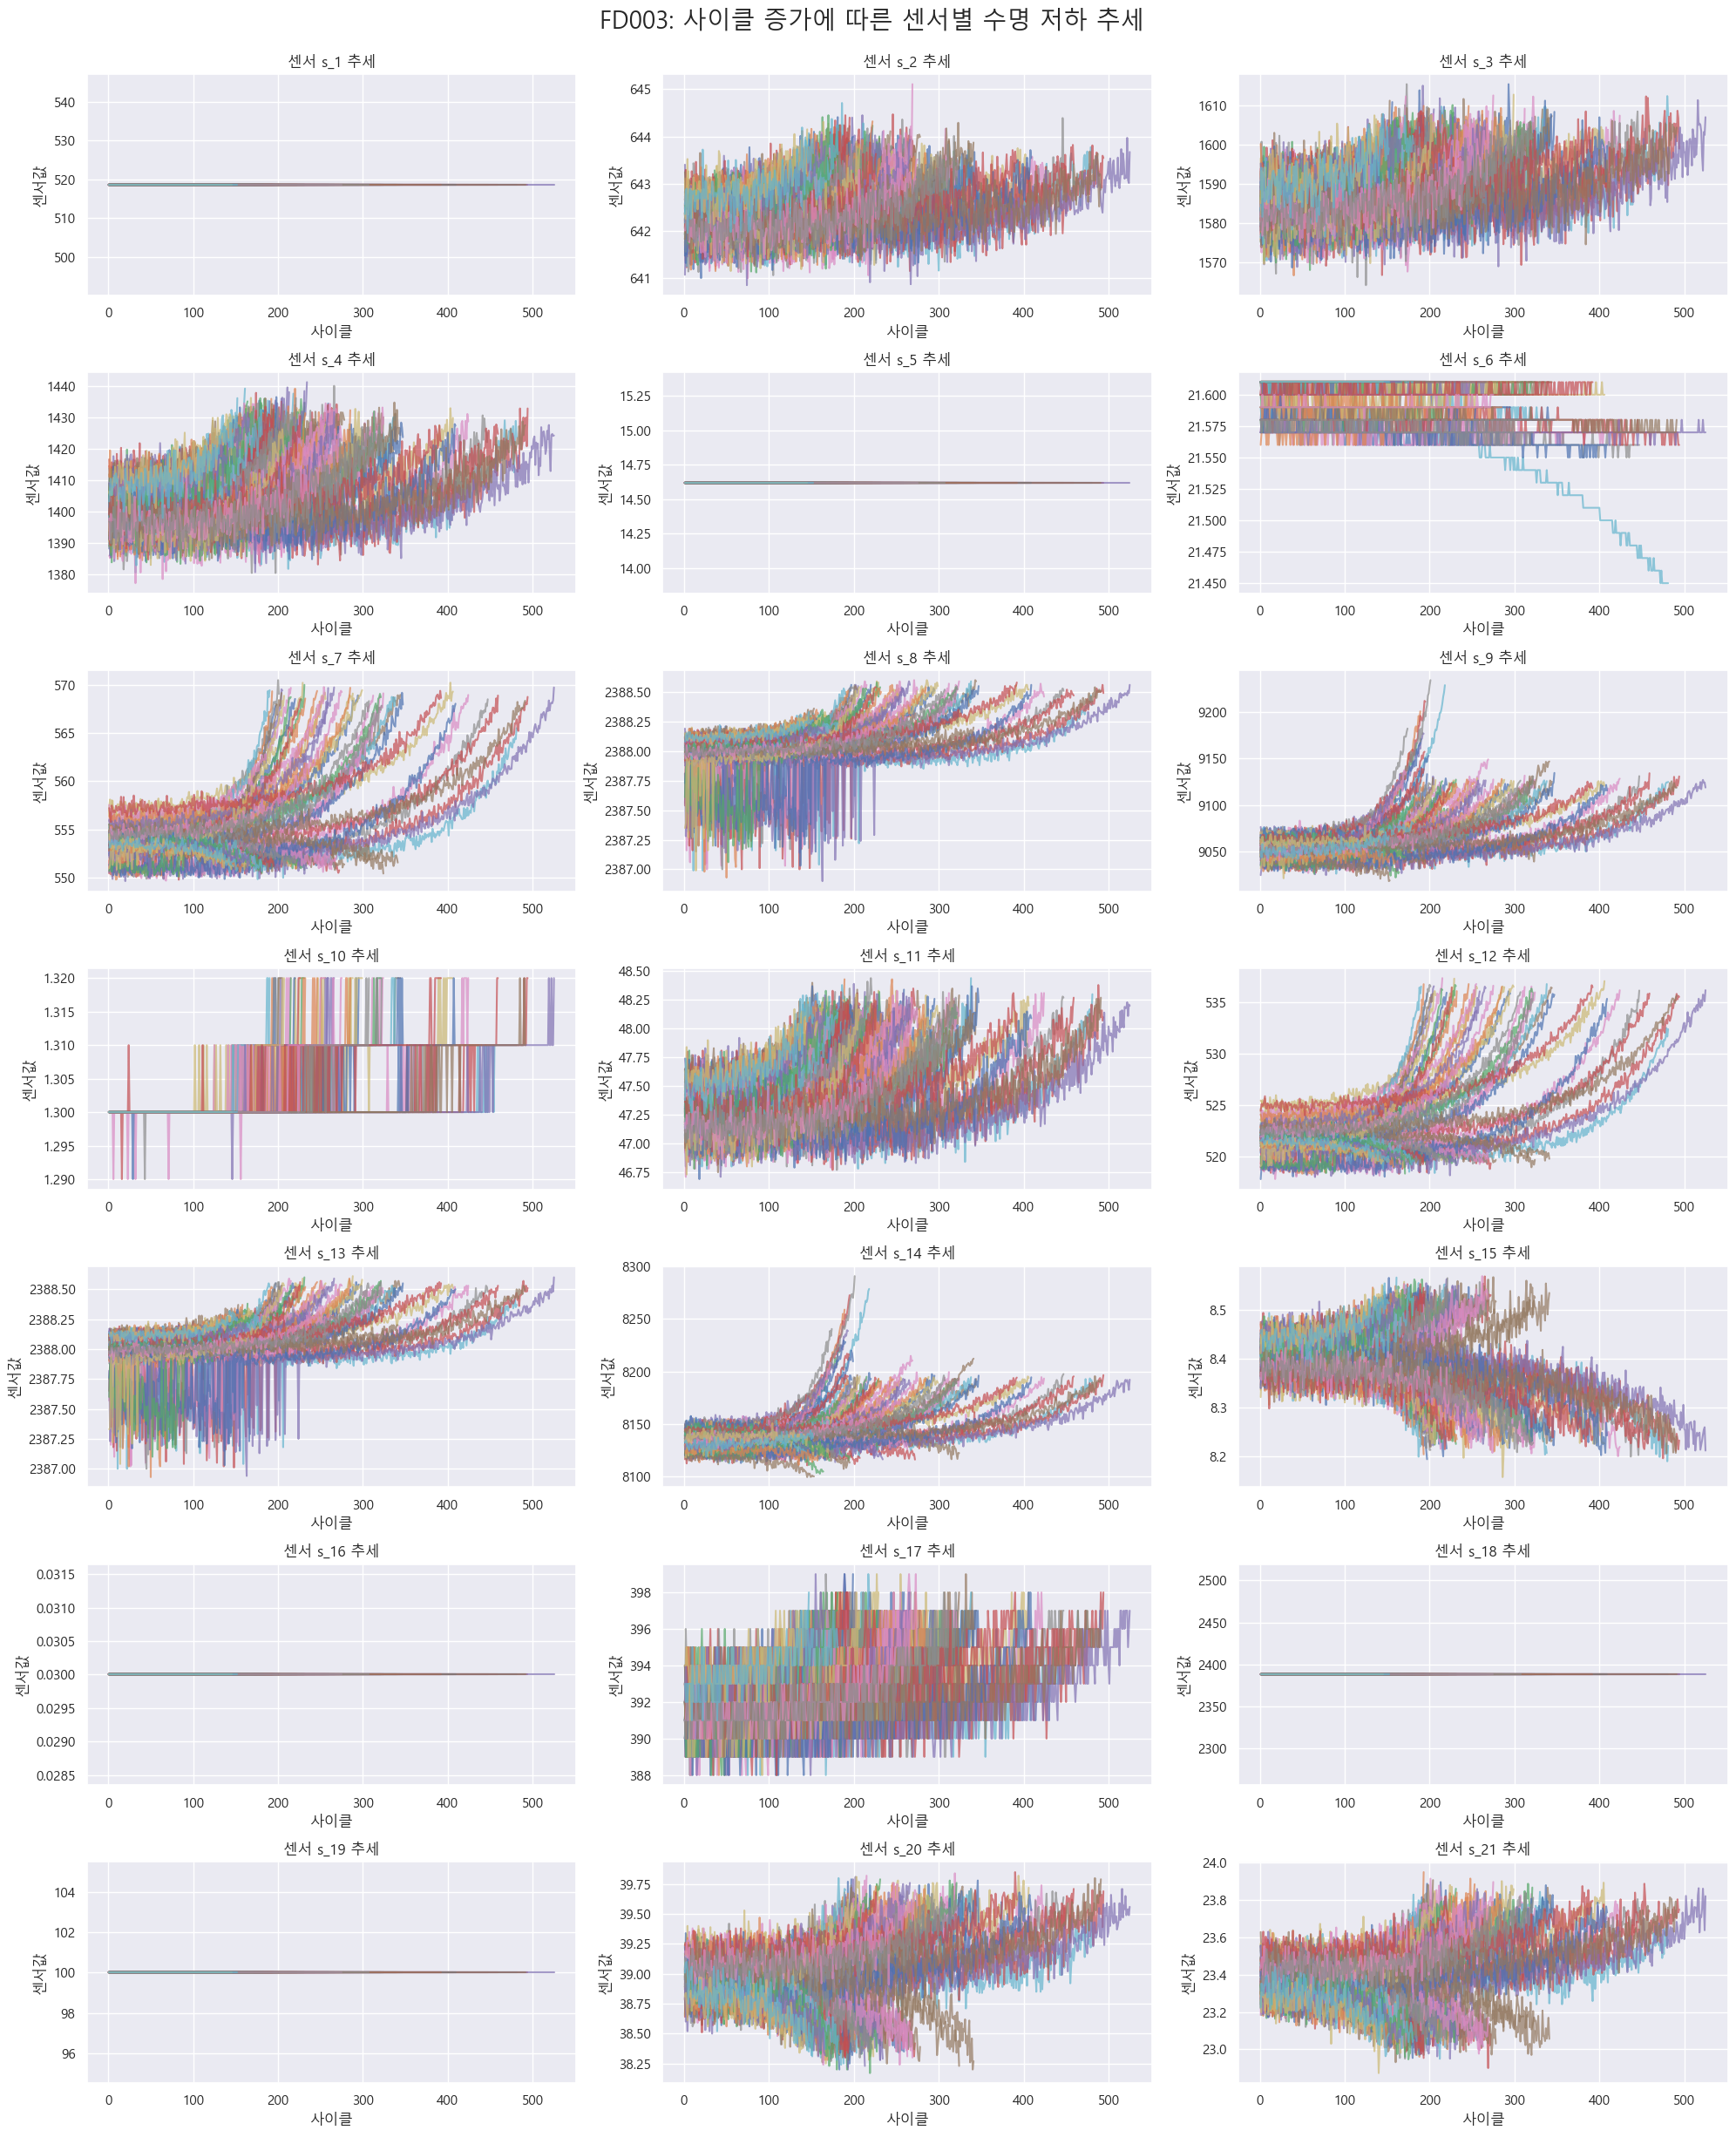

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="darkgrid", font='Malgun Gothic')

# 3. 센서 컬럼 리스트
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]

# 4. 시각화 (7행 3열 구조로 21개 센서 표시)
fig, axes = plt.subplots(7, 3, figsize=(20, 25))
axes = axes.flatten()

# 모든 엔진을 다 그리면 너무 복잡하므로, 샘플로 몇 개의 엔진만 선택해서 그립니다.
sample_units = df_train3['unit_nr'].unique()  # 상위 5개 엔진만 샘플링

for i, sensor in enumerate(sensor_names):
    for unit in sample_units:
        unit_data = df_train3[df_train3['unit_nr'] == unit]
        axes[i].plot(unit_data['time_cycles'], unit_data[sensor], alpha=0.7, label=f'Unit {unit}')
    
    axes[i].set_title(f'센서 {sensor} 추세', fontsize=12)
    axes[i].set_xlabel('사이클')
    axes[i].set_ylabel('센서값')

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle('FD003: 사이클 증가에 따른 센서별 수명 저하 추세', fontsize=20)
plt.show()

In [16]:
# 상관계수 계산 및 시각화 코드
def plot_correlation_with_rul(df, sensor_cols):
    corrs = df[sensor_cols + ['RUL']].corr()['RUL'].sort_values(ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=corrs.values, y=corrs.index, palette='coolwarm')
    plt.title('Sensor Correlation with RUL (FD003)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# 실행: df_train에서 센서만 추출하여 확인
sensor_cols = [c for c in df_train3.columns if c.startswith('s_')]
plot_correlation_with_rul(df_train3, sensor_cols)

KeyError: "['RUL'] not in index"

ValueError: num must be an integer with 1 <= num <= 15, not 16

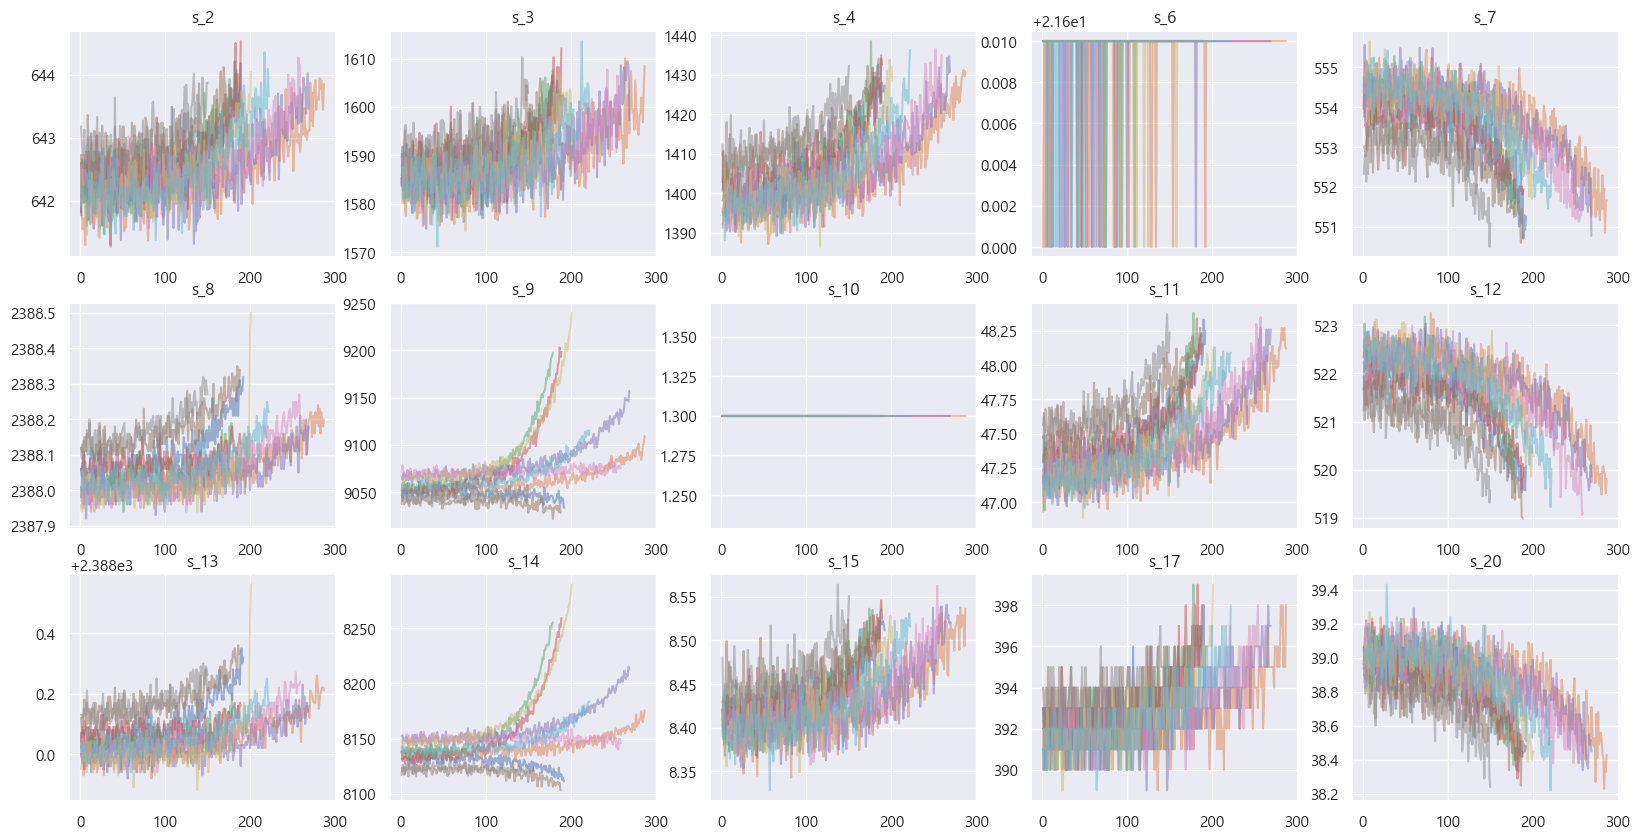

In [17]:
def plot_sensor_trends(df, unit_ids, sensors_to_plot):
    plt.figure(figsize=(20, 10))
    for i, sensor in enumerate(sensors_to_plot, 1):
        plt.subplot(3, 5, i)
        for uid in unit_ids:
            unit_data = df[df['unit_nr'] == uid]
            plt.plot(unit_data['time_cycles'].values, unit_data[sensor].values, alpha=0.5)
        plt.title(sensor)
    plt.tight_layout()
    plt.show()

# 주요 센서 15개 시각화 (샘플 유닛 10개)
sample_units = df_train3['unit_nr'].unique()[:10]
plot_sensor_trends(df_train3, sample_units, CONFIG['BASE_SENSORS'])

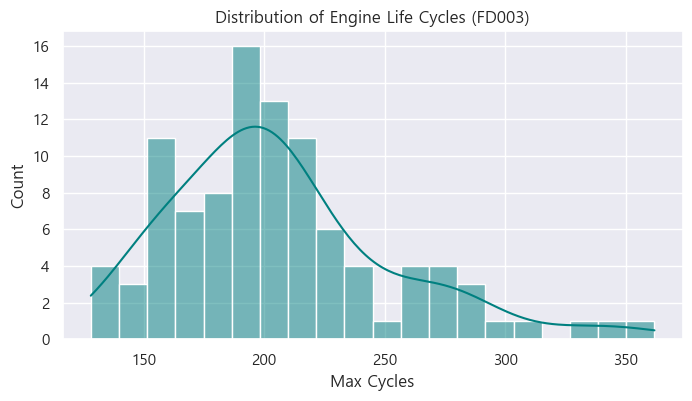

In [18]:
# 엔진 수명 분포 시각화
max_cycles = df_train3.groupby('unit_nr')['time_cycles'].max()
plt.figure(figsize=(8, 4))
sns.histplot(max_cycles, bins=20, kde=True, color='teal')
plt.title('Distribution of Engine Life Cycles (FD003)')
plt.xlabel('Max Cycles')
plt.show()

C:\Users\yesyo\AppData\Local\Temp\ipykernel_31940\2777668196.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='stage', y=col, palette={'Early': 'skyblue', 'Late': 'salmon'})
C:\Users\yesyo\AppData\Local\Temp\ipykernel_31940\2777668196.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='stage', y=col, palette={'Early': 'skyblue', 'Late': 'salmon'})
C:\Users\yesyo\AppData\Local\Temp\ipykernel_31940\2777668196.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='stage', y=col, p

ValueError: num must be an integer with 1 <= num <= 16, not 17

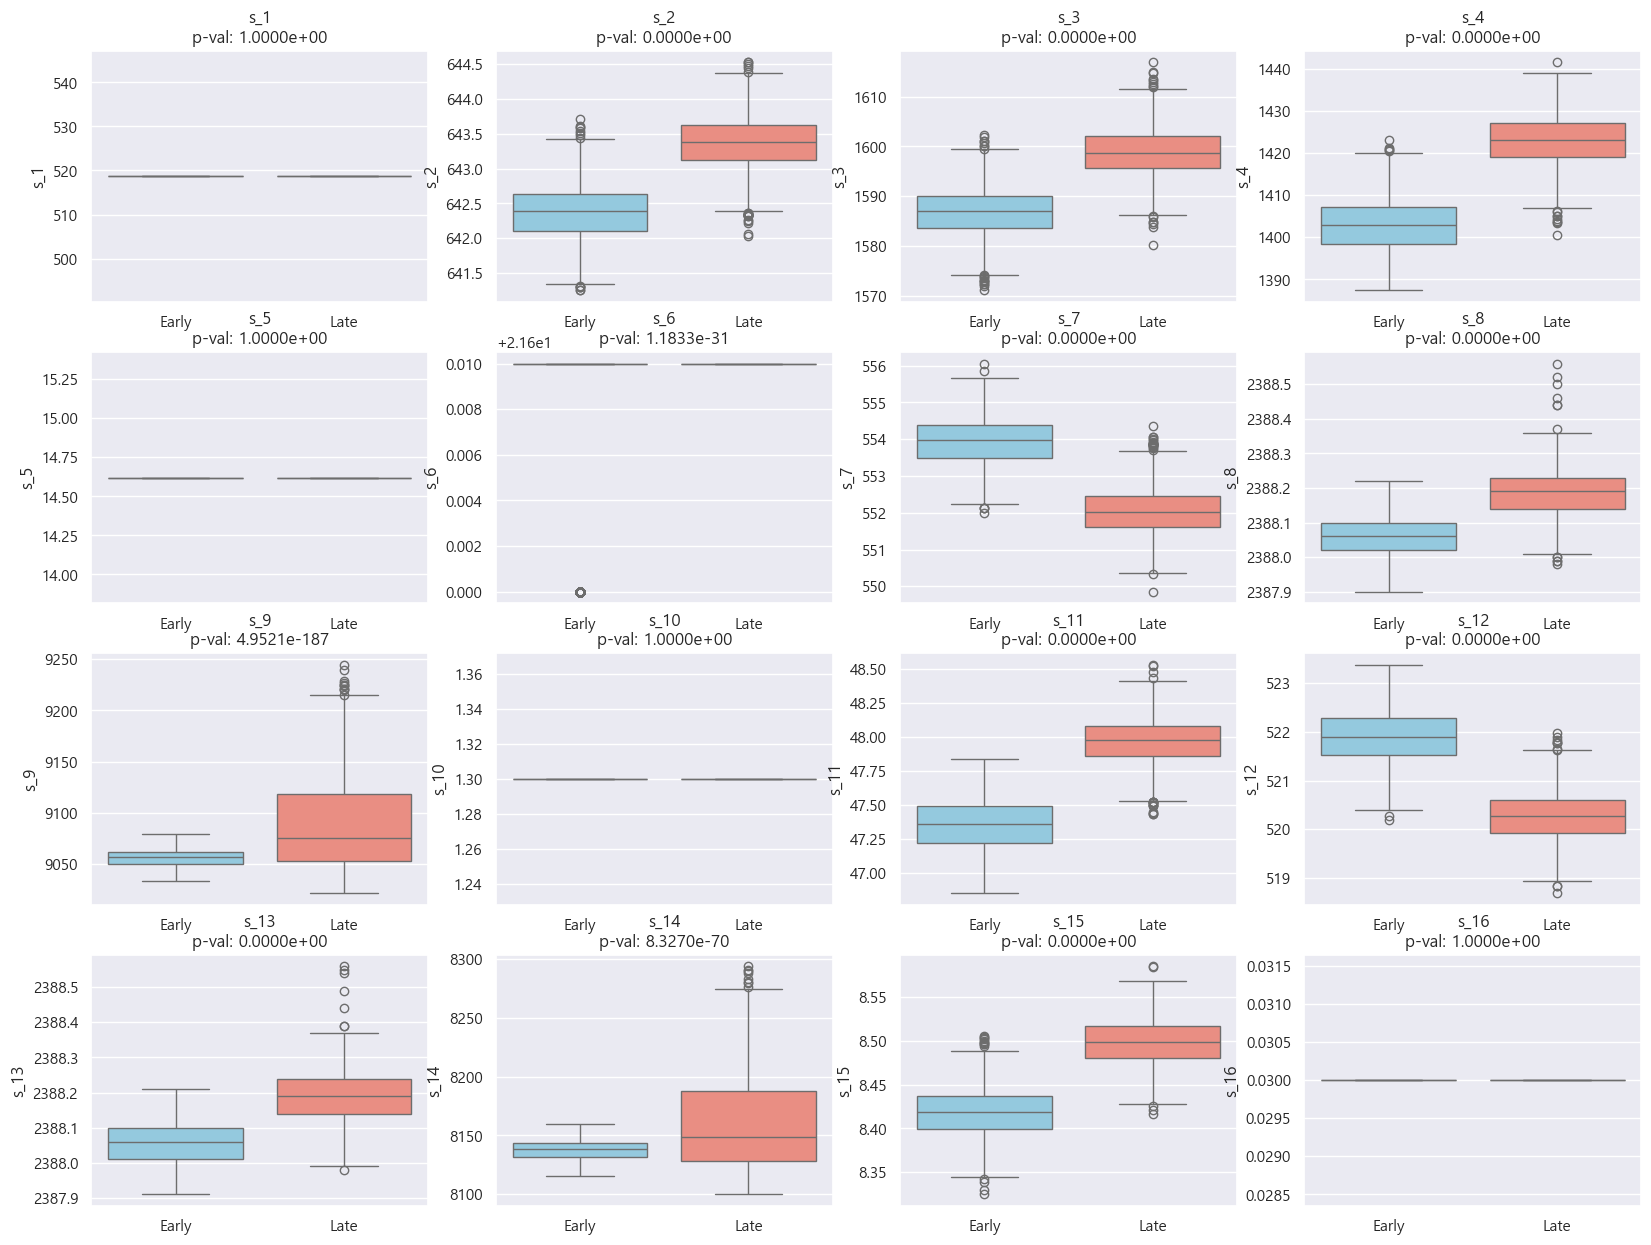

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# 1. 데이터 레이블링 (초기 vs 말기)
def label_life_stages(df, window=30):
    df = df.copy()
    # 초기 상태: 1~window 사이클
    # 말기 상태: max_cycle - window 이후
    max_cycles = df.groupby('unit_nr')['time_cycles'].transform('max')
    df['stage'] = 'Stable'
    df.loc[df['time_cycles'] <= window, 'stage'] = 'Early'
    df.loc[df['time_cycles'] > (max_cycles - window), 'stage'] = 'Late'
    
    # Early와 Late만 필터링
    return df[df['stage'] != 'Stable']

# 2. 가설 검정 및 시각화 실행
def analyze_sensors_statistical(df, sensor_cols):
    analysis_df = label_life_stages(df)
    
    results = []
    plt.figure(figsize=(20, 15))
    
    for i, col in enumerate(sensor_cols, 1):
        # 데이터 분리
        early_vals = analysis_df[analysis_df['stage'] == 'Early'][col]
        late_vals = analysis_df[analysis_df['stage'] == 'Late'][col]
        
        # Mann-Whitney U test
        stat, p_value = mannwhitneyu(early_vals, late_vals, alternative='two-sided')
        
        # 결과 저장
        results.append({
            'sensor': col,
            'p_value': p_value,
            'significant': p_value < 0.05,
            'mean_diff': late_vals.mean() - early_vals.mean()
        })
        
        # Boxplot 시각화
        plt.subplot(4, 4, i)
        sns.boxplot(data=analysis_df, x='stage', y=col, palette={'Early': 'skyblue', 'Late': 'salmon'})
        plt.title(f"{col}\np-val: {p_value:.4e}")
        plt.xlabel('')
        
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results)

# 실행 (df_train 데이터 기준)
sensor_cols = [f's_{i}' for i in range(1, 22)]
stat_results = analyze_sensors_statistical(df_train3, sensor_cols)

# 결과 요약 출력
print("\n--- 통계적 유의성 검정 결과 (P-value < 0.05 시 유효) ---")
print(stat_results.sort_values(by='p_value'))

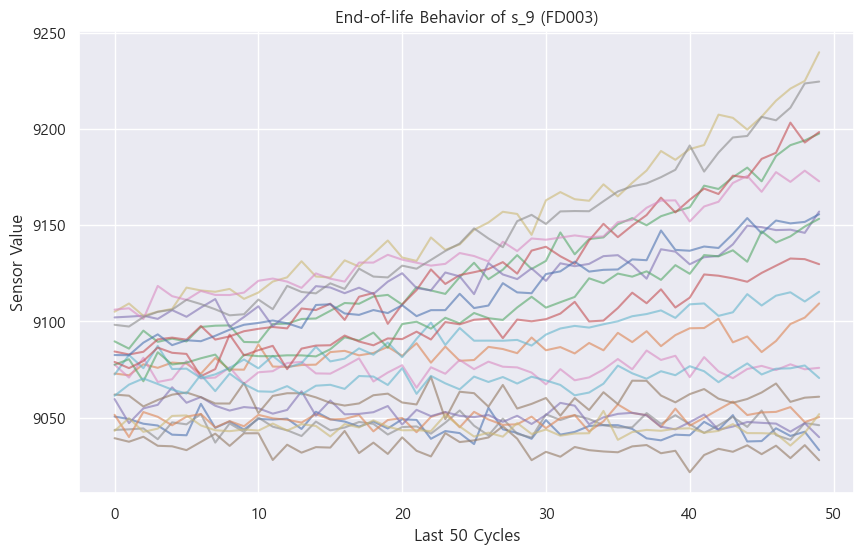

In [23]:
# [검증용 코드] 특정 센서의 끝부분 거동 확인
def check_fault_modes(df, sensor_name='s_9'):
    plt.figure(figsize=(10, 6))
    sample_units = df['unit_nr'].unique()[:20] # 20개 엔진 샘플
    
    for uid in sample_units:
        unit_data = df[df['unit_nr'] == uid]
        # 엔진 수명의 마지막 50사이클만 시각화
        tail_data = unit_data.tail(50)
        plt.plot(range(len(tail_data)), tail_data[sensor_name].values, alpha=0.6)
        
    plt.title(f"End-of-life Behavior of {sensor_name} (FD003)")
    plt.xlabel("Last 50 Cycles")
    plt.ylabel("Sensor Value")
    plt.show()

# 실행해보면 어떤 엔진은 값이 위로 튀고, 어떤 엔진은 아래로 꺾이는 식의 
# '두 갈래 길'이 보이는 센서가 있을 겁니다. (예: s_9, s_14 등)
check_fault_modes(df_train3, 's_9')

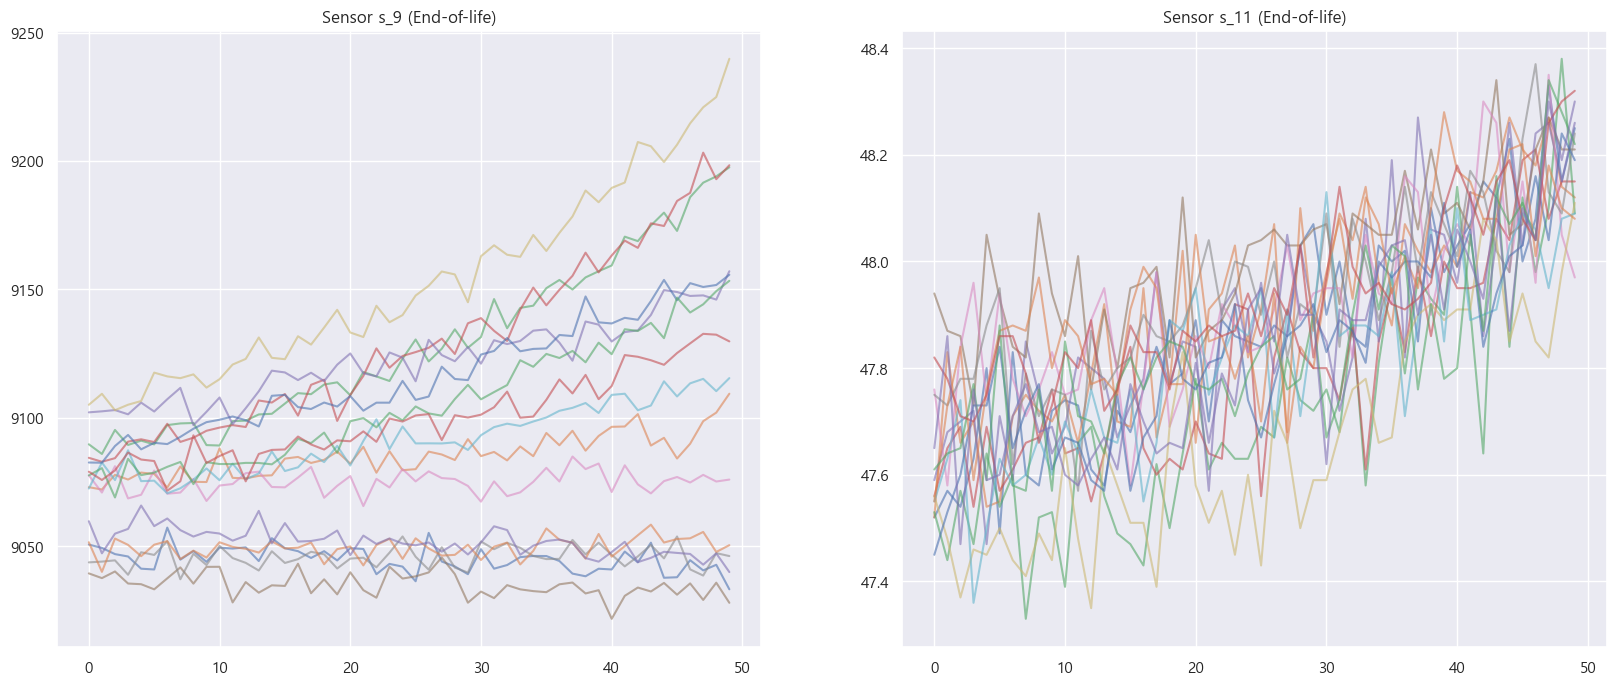

In [24]:
# 두 개의 핵심 센서를 비교해서 고장 모드 차이 확인
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sample_units = df_train3['unit_nr'].unique()[:15]

for uid in sample_units:
    unit_data = df_train3[df_train3['unit_nr'] == uid].tail(50)
    # s_9: 어떤 엔진은 반응하고 어떤 엔진은 안 함
    ax1.plot(unit_data['s_9'].values, alpha=0.6)
    # s_11: s_9이 조용할 때 s_11이 튀는지 확인
    ax2.plot(unit_data['s_11'].values, alpha=0.6)

ax1.set_title("Sensor s_9 (End-of-life)")
ax2.set_title("Sensor s_11 (End-of-life)")
plt.show()